In [ ]:
#Imports Pandas as Pd
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
#Load the dataset
url=" https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv"
df = pd.read_csv(url)
df.head()

/tmp/ipykernel_876/2943052893.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Unique Key,Created Date,Closed Date,Agency,Complaint Type,Location Type,Incident Zip,Incident Address,Street Name,Address Type,...,Landmark,Facility Type,Status,Due Date,Resolution Description,BBL,Borough,Latitude,Longitude,Location
0,42680103,5/1/2019 0:00,5/16/2019 21:45,DEP,Water System,NaN,11420.0,127-16 111 AVENUE,111 AVENUE,ADDRESS,...,NaN,NaN,Closed,NaN,The Department of Environment Protection inspe...,4.116320e+09,QUEENS,40.682565,-73.814060,"(40.682565064146196, -73.81406015056832)"
1,42530481,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10011.0,207 WEST 14 STREET,WEST 14 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 22:17,Callers should contact the DOHMH Foodborne Ill...,1.007640e+09,MANHATTAN,40.738791,-74.000224,"(40.738790792032844, -74.00022373020307)"
2,42527619,5/1/2019 0:00,5/13/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,10025.0,2664 BROADWAY,BROADWAY,ADDRESS,...,NaN,NaN,Closed,5/15/2019 10:04,The Department of Health and Mental Hygiene wi...,1.018730e+09,MANHATTAN,40.798040,-73.969300,"(40.79804015465285, -73.96930001020544)"
3,42526597,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11208.0,624 SOUTH CONDUIT BOULEVARD,SOUTH CONDUIT BOULEVARD,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:27,The Department of Health and Mental Hygiene wi...,3.042380e+09,BROOKLYN,40.675905,-73.866660,"(40.67590510222738, -73.86665990579837)"
4,42526595,5/1/2019 0:00,5/2/2019 0:00,DOHMH,Food Poisoning,Restaurant/Bar/Deli/Bakery,11106.0,31-91 21 STREET,21 STREET,ADDRESS,...,NaN,NaN,Closed,5/15/2019 17:12,The Department of Health and Mental Hygiene wi...,4.005540e+09,QUEENS,40.765367,-73.931540,"(40.76536704921336, -73.93154011254339)"


In [ ]:
#How many rows and colums are there
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 69637
Number of columns: 21


In [ ]:
#What is the time range of this dataset
print("First date:", df["Created Date"].min())
print("Last date:", df["Created Date"].max())


First date: 5/1/2019 0:00
Last date: 5/9/2019 9:59


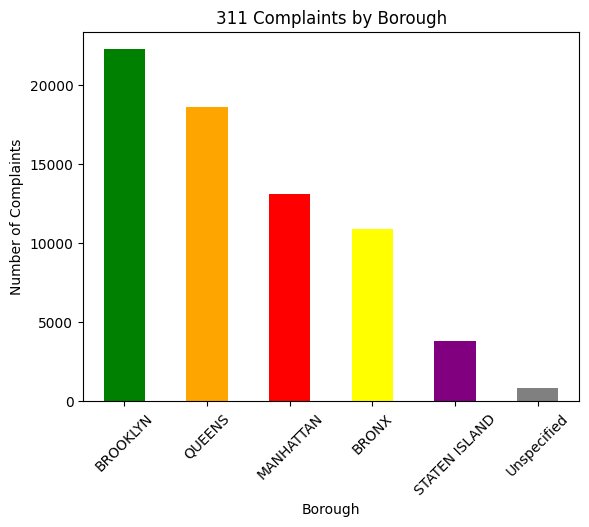

In [ ]:
#Vizualizations Parts  or Summary Statistics
# 1-Complaints by borough
borough_colors = {
"BROOKLYN": "green",
"QUEENS": "orange",
"MANHATTAN": "Red",
"BRONX": "yellow",
"STATEN ISLAND": "purple",
"Unspecified": "gray"
}

borough_counts = df["Borough"].value_counts()

borough_counts.plot(
kind="bar",
color=[borough_colors.get(borough, "gray") for borough in borough_counts.index]
)

plt.title("311 Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

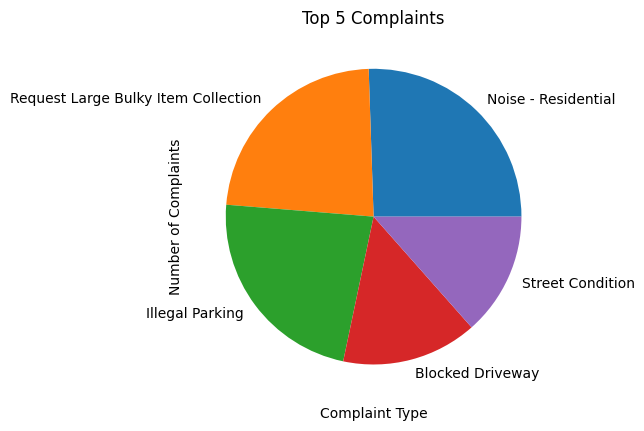

In [ ]:
#2-Top 5 complaints
top_complaints = df["Complaint Type"].value_counts().head(5)
top_complaints.plot(kind="pie")
plt.title("Top 5 Complaints")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.show()

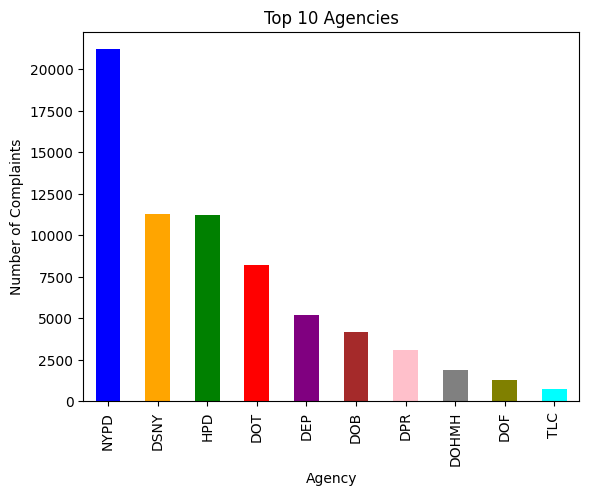

In [ ]:
# Top 10 Agencies
df["Agency"].value_counts().head(10).plot(
     kind="bar",
color=["blue", "orange","green","red","purple","brown","pink","gray","olive", "cyan"])
plt.title("Top 10 Agencies")
plt.xlabel("Agency")
plt.ylabel("Number of Complaints")
plt.show()

In [ ]:
#5-What borough has the most complaints?
df["Borough"].value_counts().head(1)

,count
Borough,
BROOKLYN,22247


In [ ]:
#6- Create a plot of counts by borough for noise complaints
#1-Find the noise complaints
noise = df[df["Complaint Type"].str.contains("Noise",na=False)]


In [ ]:
#2-Count the Noise by borough
noise["Borough"].value_counts()

,count
Borough,
MANHATTAN,3779
BROOKLYN,3294
QUEENS,2892
BRONX,2006
STATEN ISLAND,275
Unspecified,19


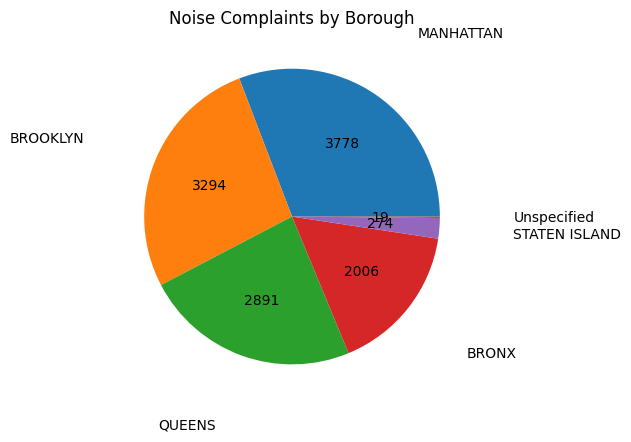

In [ ]:
#3-Make the noise graph
noise_counts = noise["Borough"].value_counts()

noise_counts.plot(
kind="pie",
autopct=lambda p: int(p/100 * noise_counts.sum()),
labeldistance=1.5
)

plt.title("Noise Complaints by Borough")
plt.ylabel("")

plt.show()

In [ ]:
#7 Find one more interesting piece of information
df["Complaint Type"].value_counts().head(1)

,count
Complaint Type,
Noise - Residential,5838


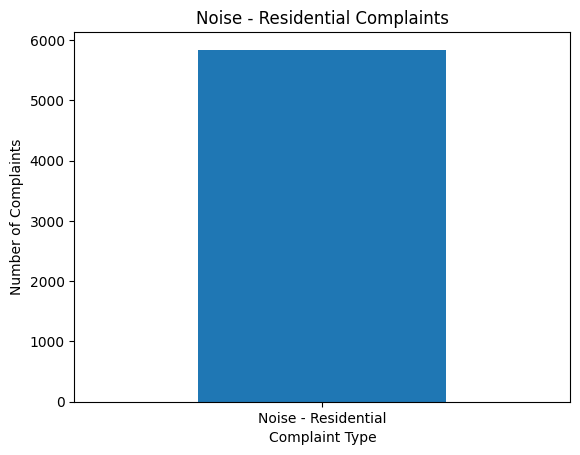

In [ ]:
# Interesting finding:
#I found that there were 5838 noise-residential complaints This show that in NYC residential noise was
# a common reason people contacted NYC 311.
residential = df[df["Complaint Type"] == "Noise - Residential"]

residential["Complaint Type"].value_counts().plot(kind="bar")

plt.title("Noise - Residential Complaints")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)

plt.show()